# Data ingest

In [1]:
# imports

import datetime as dt
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
dataset_path = Path(
    kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
)

files = list(dataset_path.iterdir())
print([file.name for file in files])

data_file = next(
    file for file in files
    if file.suffix.lower() in {".xlsx", ".xls", ".csv"}
)

df = pd.read_csv(data_file)

df.to_csv("../01_data/01_raw_data/customer_original.csv", index=False)

df

['online_retail_II.csv']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [3]:
# -----------
# DATA AUDIT
# -----------

df.shape

(1067371, 8)

In [4]:
df.dtypes

# Need new Format: InvoiceDate (date), Customer ID (str)

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [5]:
df.isna().sum()

# Missing Values: Customer ID without ID, Description

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [6]:
df.describe()

# Negative values: Quantity, Price

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


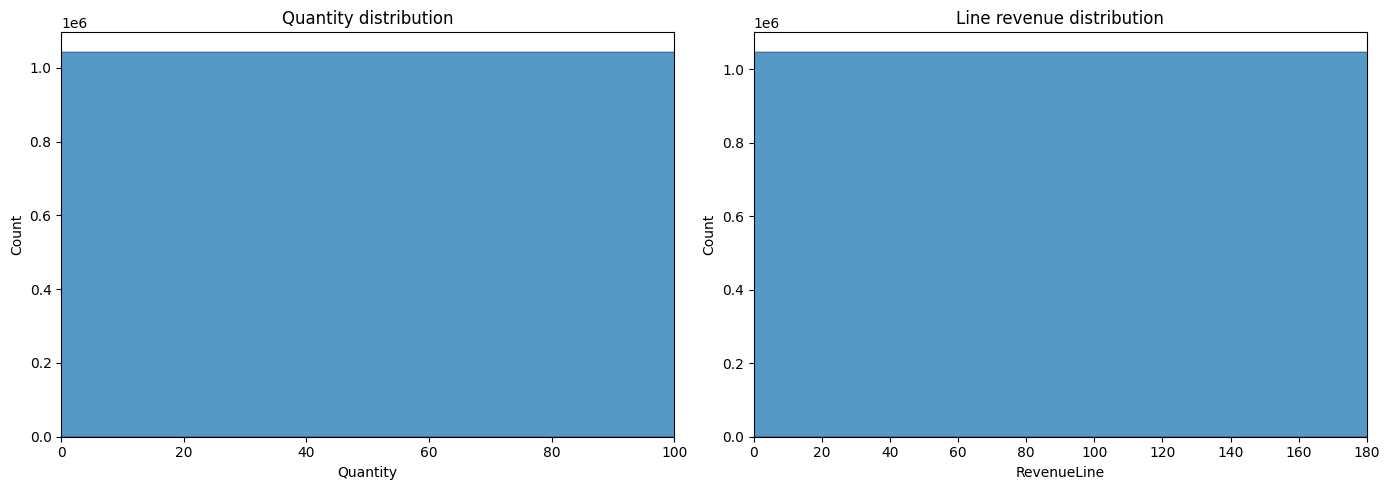

In [11]:
df['RevenueLine'] = df['Quantity']*df['Price']


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df['Quantity'],
    bins=100,
    ax=axes[0]
)
axes[0].set_title('Quantity distribution')
axes[0].set_xlim(0, df['Quantity'].quantile(0.99))

sns.histplot(
    df['RevenueLine'],
    bins=100,
    ax=axes[1]
)
axes[1].set_title('Line revenue distribution')
axes[1].set_xlim(0, df['RevenueLine'].quantile(0.99))

plt.tight_layout()
plt.show()

In [14]:
df["Invoice"] = df["Invoice"].astype(str)

df["is_cancellation"] = df["Invoice"].str.startswith("C", na=False)
df["is_return"] = df["Quantity"].lt(0)
df["is_non_positive_price"] = df["Price"].le(0)  # falls Price vorhanden

purchases = df[
    df["Customer ID"].notna()
    & df["InvoiceDate"].notna()
    & df["Description"].notna()
    & df["Quantity"].gt(0)
    & df["Price"].gt(0)
    & ~df["is_cancellation"]
].copy()

purchases["RevenueLine"] = (
    purchases["Quantity"] * purchases["Price"]
)

In [16]:
df.nlargest(
    20,
    "Quantity"
)[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "RevenueLine",
        "Customer ID",
        "InvoiceDate",
    ]
]

,Invoice,StockCode,Description,Quantity,Price,RevenueLine,Customer ID,InvoiceDate
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,2011-12-09 09:15:00
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,2011-01-18 10:01:00
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,1915.20,13902.0,2010-02-15 11:57:00
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,1296.00,13902.0,2010-03-17 13:09:00
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,1296.00,13902.0,2010-03-17 13:09:00
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,1274.40,13902.0,2010-03-17 13:09:00
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,0.00,13256.0,2011-11-25 15:57:00
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,1248.00,13902.0,2010-03-17 13:09:00
192197,507637,84016,FLAG OF ST GEORGE CAR FLAG,10200,0.00,0.00,NaN,2010-05-10 14:55:00
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,2500.00,17940.0,2010-03-23 15:36:00


In [19]:
df.nlargest(
    20,
    "RevenueLine"
)[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "RevenueLine",
        "Customer ID",
        "InvoiceDate",
    ]
]

,Invoice,StockCode,Description,Quantity,Price,RevenueLine,Customer ID,InvoiceDate
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,2011-12-09 09:15:00
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,2011-01-18 10:01:00
748132,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,2011-06-10 15:28:00
241827,512771,M,Manual,1,25111.09,25111.09,NaN,2010-06-17 16:53:00
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,15818.40,15838.0,2010-11-04 11:36:00
517955,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,2010-12-07 15:08:00
540478,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,2010-12-07 15:08:00
825443,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,2011-08-12 14:50:00
135013,502263,M,Manual,1,10953.50,10953.50,12918.0,2010-03-23 15:22:00
135015,502265,M,Manual,1,10953.50,10953.50,NaN,2010-03-23 15:28:00


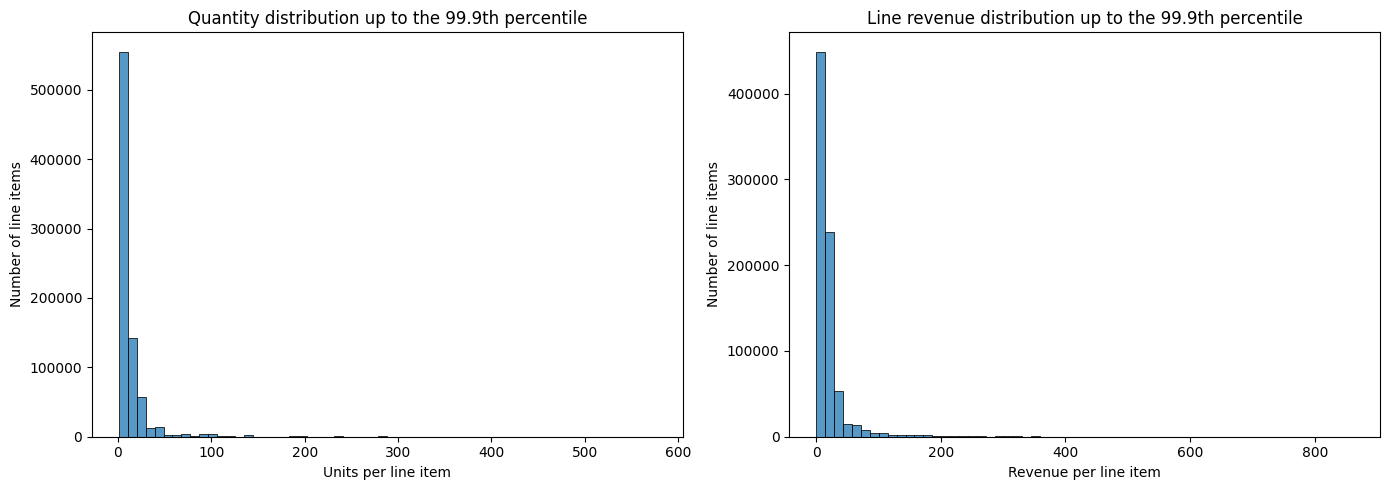

In [20]:
quantity_upper = purchases["Quantity"].quantile(0.999)
revenue_upper = purchases["RevenueLine"].quantile(0.999)

plot_purchases = purchases[
    (purchases["Quantity"] <= quantity_upper)
    & (purchases["RevenueLine"] <= revenue_upper)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=plot_purchases,
    x="Quantity",
    bins=60,
    ax=axes[0]
)
axes[0].set_title(
    "Quantity distribution up to the 99.9th percentile"
)
axes[0].set_xlabel("Units per line item")
axes[0].set_ylabel("Number of line items")

sns.histplot(
    data=plot_purchases,
    x="RevenueLine",
    bins=60,
    ax=axes[1]
)
axes[1].set_title(
    "Line revenue distribution up to the 99.9th percentile"
)
axes[1].set_xlabel("Revenue per line item")
axes[1].set_ylabel("Number of line items")

plt.tight_layout()
plt.show()